In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
data= pd.read_csv('E:/SAMEEKSH/amazon.csv',encoding="iso-8859-1", parse_dates=['date'])

In [10]:
data.dtypes

year               int64
state             object
month             object
number           float64
date      datetime64[ns]
dtype: object

## **1.Check first 5 Rows of The Dataset**


In [12]:
data.head()

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01


## **2. Check Last 5 Rows of The Dataset**

In [13]:
data.tail()

,year,state,month,number,date
6449,2012,Tocantins,Dezembro,128.0,2012-01-01
6450,2013,Tocantins,Dezembro,85.0,2013-01-01
6451,2014,Tocantins,Dezembro,223.0,2014-01-01
6452,2015,Tocantins,Dezembro,373.0,2015-01-01
6453,2016,Tocantins,Dezembro,119.0,2016-01-01


## **3. Find Shape of Our Dataset (Number of Rows And Number of Columns)**

In [15]:
data.shape

(6454, 5)

In [16]:
print("Number of Rows", data.shape[0])
print("Number of Columns", data.shape[1])

Number of Rows 6454
Number of Columns 5


## **4. Getting Information About Our Dataset Like Total Number Rows, Total Number of Columns, Datatypes of Each Column And Memory Requirement**

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   year    6454 non-null   int64         
 1   state   6454 non-null   object        
 2   month   6454 non-null   object        
 3   number  6454 non-null   float64       
 4   date    6454 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 252.2+ KB


## **5. Check For Duplicate Data and Drop Them**

In [19]:

print("Total Duplicate Rows:", data.duplicated().sum())


data = data.drop_duplicates()


print("Shape After Removing Duplicates:", data.shape)

Total Duplicate Rows: 32
Shape After Removing Duplicates: (6422, 5)


## **6. Check Null Values In The Dataset**

In [20]:
print(data.isnull().sum())

year      0
state     0
month     0
number    0
date      0
dtype: int64


## **7. Get Overall Statistics About The DataFrame**

In [21]:
data.describe(include='all')

,year,state,month,number,date
count,6422.000000,6422,6422,6422.000000,6422
unique,NaN,23,12,NaN,NaN
top,NaN,Rio,Agosto,NaN,NaN
freq,NaN,697,540,NaN,NaN
mean,2007.490969,NaN,NaN,108.815178,2007-06-29 10:46:40.622859008
min,1998.000000,NaN,NaN,0.000000,1998-01-01 00:00:00
25%,2003.000000,NaN,NaN,3.000000,2003-01-01 00:00:00
50%,2007.000000,NaN,NaN,24.497000,2007-01-01 00:00:00
75%,2012.000000,NaN,NaN,114.000000,2012-01-01 00:00:00
max,2017.000000,NaN,NaN,998.000000,2017-01-01 00:00:00


## **8. Rename Month Names To English**

In [22]:
data['month'] = data['month'].replace({
    'Janeiro': 'January',
    'Fevereiro': 'February',
    'Março': 'March',
    'Abril': 'April',
    'Maio': 'May',
    'Junho': 'June',
    'Julho': 'July',
    'Agosto': 'August',
    'Setembro': 'September',
    'Outubro': 'October',
    'Novembro': 'November',
    'Dezembro': 'December'
})

data['month'].unique()

array(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype=object)

## **9. Find Total Number of Fires Registered**

In [23]:
print("Total Number of Fires Registered:",
      data['number'].sum())

Total Number of Fires Registered: 698811.073


## **10. In Which Month Maximum Number of Forest Fires Were Reported?**

In [24]:
data.groupby('month')['number']\
    .sum()\
    .sort_values(ascending=False)\
    .head(1)

month
July    92319.113
Name: number, dtype: float64

## **11. In Which Year Maximum Number of Forest Fires Was Reported?**

In [26]:
data.groupby('year')['number']\
    .sum()\
    .sort_values(ascending=False)\
    .head(1)

year
2003    42760.674
Name: number, dtype: float64

## **12. In Which State Maximum Number of Forest Fires Was Reported?**

In [27]:
data.groupby('state')['number']\
    .sum()\
    .sort_values(ascending=False)\
    .head(1)

state
Mato Grosso    96246.028
Name: number, dtype: float64

## **13. Find Total Number of Fires Were Reported In Amazonas**

In [29]:
amazonas = data[data['state'] == 'Amazonas']

print("Total Fires Reported In Amazonas:",
      amazonas['number'].sum())

Total Fires Reported In Amazonas: 30650.129


## **14. Display Number of Fires Were Reported In Amazonas (Year-Wise)**

In [30]:
amazonas.groupby('year')['number']\
         .sum()\
         .reset_index()

,year,number
0,1998,946.000
1,1999,1061.000
2,2000,853.000
3,2001,1297.000
4,2002,2852.000
5,2003,1524.268
6,2004,2298.207
7,2005,1657.128
8,2006,997.640
9,2007,589.601


## **15. Display Number of Fires Were Reported In Amazonas (Day-Wise)**

In [31]:
# Convert date column into datetime format
data['date'] = pd.to_datetime(data['date'])

amazonas = data[data['state'] == 'Amazonas']

amazonas.groupby(amazonas['date'].dt.dayofweek)['number']\
         .sum()\
         .reset_index(name='Number_of_Fires')

,date,Number_of_Fires
0,0,1886.601
1,1,6474.217
2,2,3910.177
3,3,5754.802
4,4,5446.480
5,5,4162.666
6,6,3015.186


In [32]:
day_names = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday'
}

amazonas.groupby(amazonas['date'].dt.dayofweek)['number']\
         .sum()\
         .rename(index=day_names)

date
Monday       1886.601
Tuesday      6474.217
Wednesday    3910.177
Thursday     5754.802
Friday       5446.480
Saturday     4162.666
Sunday       3015.186
Name: number, dtype: float64

## **16. Find Total Number of Fires Were Reported In 2015 And Visualize Data Based on Each Month**

In [33]:
fire_2015 = data[data['year'] == 2015]

monthly_fire = fire_2015.groupby('month')['number']\
                         .sum()\
                         .reset_index()

monthly_fire

,month,number
0,April,2573.000
1,August,4363.125
2,December,4088.522
3,February,2309.000
4,January,4635.000
5,July,4364.392
6,June,3260.552
7,March,2202.000
8,May,2384.000
9,November,4034.518


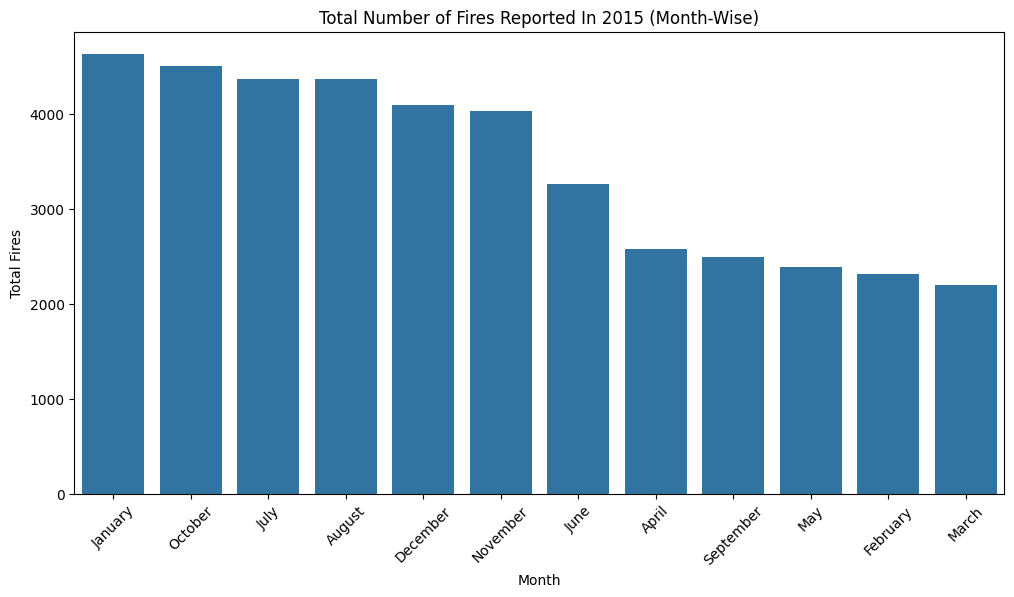

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    x='month',
    y='number',
    data=monthly_fire,
    order=monthly_fire.sort_values('number',
                                   ascending=False)['month']
)

plt.xticks(rotation=45)
plt.title('Total Number of Fires Reported In 2015 (Month-Wise)')
plt.xlabel('Month')
plt.ylabel('Total Fires')

plt.show()

## **17. Find Average Number of Fires Were Reported From Highest to Lowest (State-Wise)**

In [35]:
data.groupby('state')['number']\
    .mean()\
    .sort_values(ascending=False)\
    .reset_index(name='Average_Number_of_Fires')

,state,Average_Number_of_Fires
0,Sao Paulo,213.896226
1,Mato Grosso,203.479975
2,Bahia,187.222703
3,Piau,158.174674
4,Goias,157.721841
5,Minas Gerais,156.800243
6,Tocantins,141.037176
7,Amazonas,128.243218
8,Ceara,127.314071
9,Paraiba,111.073979


## **18. Find The State Names Where Fires Were Reported In December Month**

In [36]:
data[data['month'] == 'December']['state']\
    .drop_duplicates()\
    .reset_index(drop=True)

0                 Acre
1              Alagoas
2                Amapa
3             Amazonas
4                Bahia
5                Ceara
6     Distrito Federal
7       Espirito Santo
8                Goias
9             Maranhao
10         Mato Grosso
11        Minas Gerais
12                Pará
13             Paraiba
14          Pernambuco
15                Piau
16                 Rio
17            Rondonia
18             Roraima
19      Santa Catarina
20           Sao Paulo
21             Sergipe
22           Tocantins
Name: state, dtype: object